<center><h1>DSCI 552 - HW2</h1></center>


Name: Sanchit Bagai

USC ID: 1033382623

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('../data/Folds5x2_pp.xlsx', sheet_name='Sheet1')
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumns:")
print(df.columns.tolist())

Number of rows: 9568
Number of columns: 5

Columns:
['AT', 'V', 'AP', 'RH', 'PE']


Rows: represent the hourly observations from the power plant for the 5 variables.

Columns: represent the independent variables (AT, V, AP, RH) and hourly power output.

#### ii. pairwise scatterplots of all the varianbles

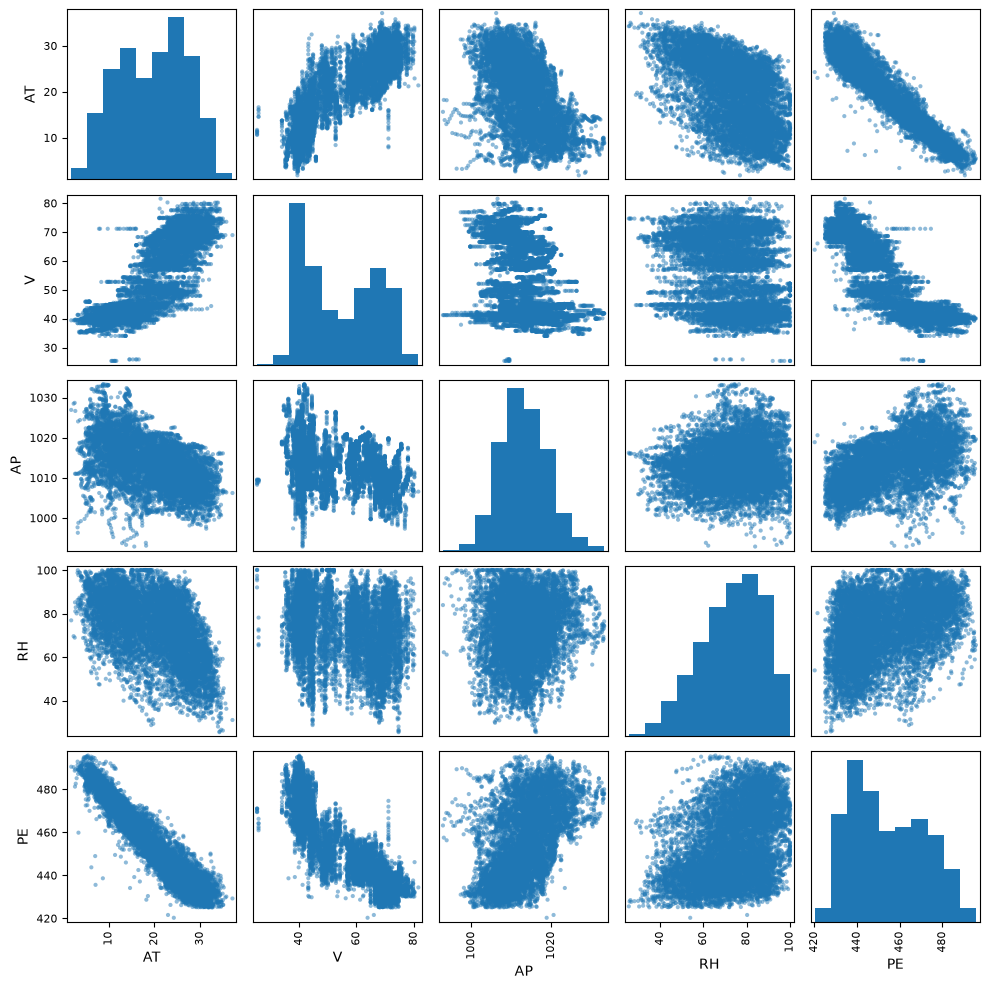

In [4]:
pd.plotting.scatter_matrix(df, figsize=(10, 10), diagonal='hist')
plt.tight_layout()
plt.show()

It seems that PE shows a strong negative relationship with AT and V. PE shows a weak positive relationship with AP and RH. Within the predictors AT and V show a strong positive correlation. 

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary.round(4)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.6512,20.345,35.30,13.5100,25.72,12.2100
V,54.3058,52.080,56.20,41.7400,66.54,24.8000
AP,1013.2591,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.3090,74.975,74.60,63.3275,84.83,21.5025
PE,454.3650,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [6]:
predictors = ['AT', 'V', 'AP', 'RH']
simple_models = {}

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df['PE']

    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:27   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

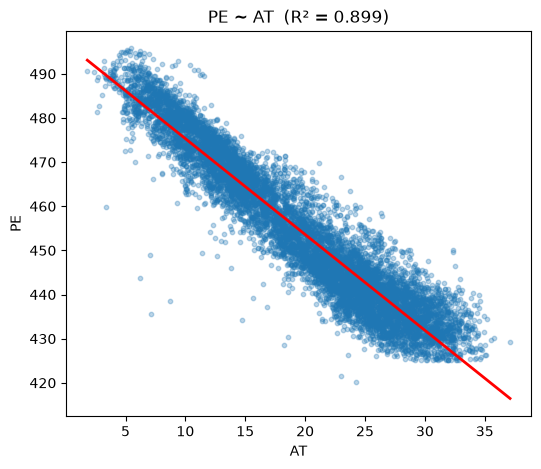

In [7]:
model = simple_models['AT']
print(model.summary())

plt.figure(figsize=(6, 5))
plt.scatter(df['AT'], df['PE'], alpha=0.3, s=10)
x_range = np.linspace(df['AT'].min(), df['AT'].max(), 100)
y_pred = model.params['const'] + model.params['AT'] * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2)
plt.xlabel('AT')
plt.ylabel('PE')
plt.title(f'PE ~ AT  (R² = {model.rsquared:.3f})')
plt.show()

It has a strong -ve association with PE with the strongest fit ($R^2 = 0.899$).

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:27   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

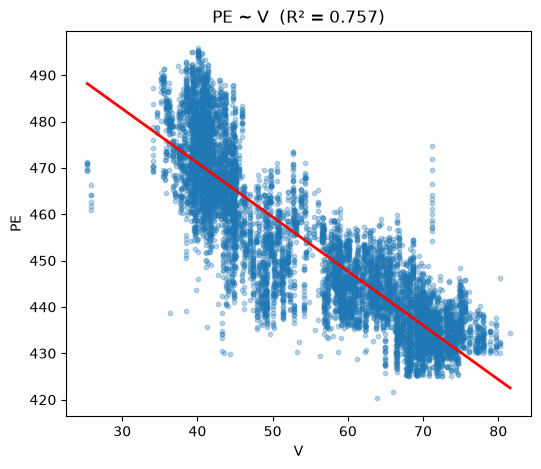

In [8]:
model = simple_models['V']
print(model.summary())

plt.figure(figsize=(6, 5))
plt.scatter(df['V'], df['PE'], alpha=0.3, s=10)
x_range = np.linspace(df['V'].min(), df['V'].max(), 100)
y_pred = model.params['const'] + model.params['V'] * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2)
plt.xlabel('V')
plt.ylabel('PE')
plt.title(f'PE ~ V  (R² = {model.rsquared:.3f})')
plt.show()

It has a strong -ve association with PE, it's a bit weaker than AT ($R^2 = 0.757$).

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:27   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

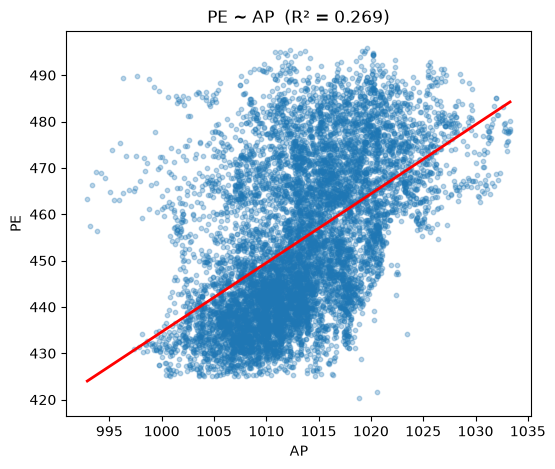

In [9]:
model = simple_models['AP']
print(model.summary())

plt.figure(figsize=(6, 5))
plt.scatter(df['AP'], df['PE'], alpha=0.3, s=10)
x_range = np.linspace(df['AP'].min(), df['AP'].max(), 100)
y_pred = model.params['const'] + model.params['AP'] * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2)
plt.xlabel('AP')
plt.ylabel('PE')
plt.title(f'PE ~ AP  (R² = {model.rsquared:.3f})')
plt.show()

It has a +ve association with PE, much weaker than the previous two ($R^2 = 0.269$).

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:27   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

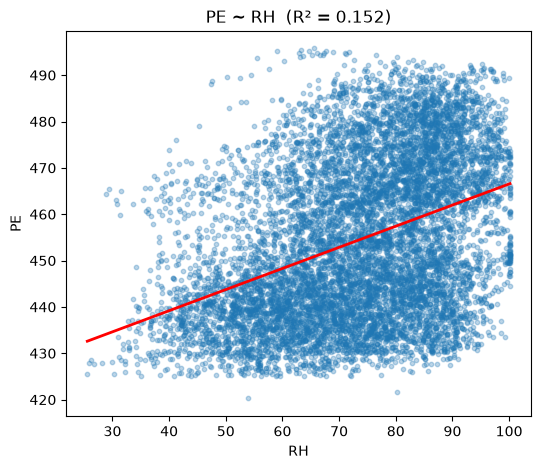

In [10]:
model = simple_models['RH']
print(model.summary())

plt.figure(figsize=(6, 5))
plt.scatter(df['RH'], df['PE'], alpha=0.3, s=10)
x_range = np.linspace(df['RH'].min(), df['RH'].max(), 100)
y_pred = model.params['const'] + model.params['RH'] * x_range
plt.plot(x_range, y_pred, color='red', linewidth=2)
plt.xlabel('RH')
plt.ylabel('PE')
plt.title(f'PE ~ RH  (R² = {model.rsquared:.3f})')
plt.show()

It has a +ve association with PE and has the weakest fit ($R^2 = 0.152$).

All 4 predictors are statistically significant with $p < 0.001$. There are some visible outliers but nothing worth removing.

### (d) Multiple Regression

In [11]:
X = sm.add_constant(df[predictors])
y = df['PE']

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

The $R^2 = 0.929$, higher than a single predictor alone. All 4 predictors are statistically significant with $p < 0.001$. So, we can reject $H_0 : \beta_j = 0$ for all predictors.

RH's coefficient flips from +ve to -ve here. It could be due to possible multicollinearity.

### (e) 1c Compare to 1d

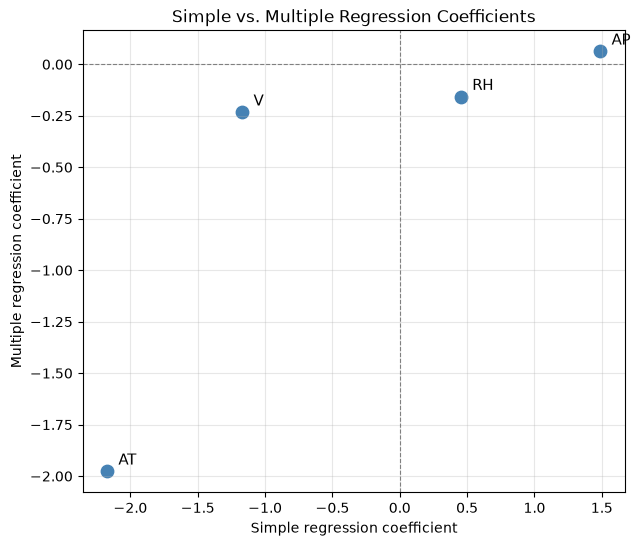

,Simple Regression Coef,Multiple Regression Coef
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


In [12]:
simple_coefs = [simple_models[p].params[p] for p in predictors]
multiple_coefs = [multiple_model.params[p] for p in predictors]

plt.figure(figsize=(7, 6))
plt.scatter(simple_coefs, multiple_coefs, s=80, color='steelblue')

for i, pred in enumerate(predictors):
    plt.annotate(pred, (simple_coefs[i], multiple_coefs[i]),
                 textcoords="offset points", xytext=(8, 5), fontsize=11)

plt.xlabel('Simple regression coefficient')
plt.ylabel('Multiple regression coefficient')
plt.title('Simple vs. Multiple Regression Coefficients')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.grid(alpha=0.3)
plt.show()

coef_comparison = pd.DataFrame({
    'Simple Regression Coef': simple_coefs,
    'Multiple Regression Coef': multiple_coefs
}, index=predictors)
coef_comparison

The coefficients shift around a bit which points towards the existence of multicollinearity. RH is the only one that flips a sign.

### (f) Nonlinear Association

In [13]:
nonlinear_models = {}

formula = 'PE ~ AT + I(AT**2) + I(AT**3)'
model_AT = smf.ols(formula=formula, data=df).fit()
nonlinear_models['AT'] = model_AT
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

AT shows evidence of non linear association as all 3 coefficients are statistically significant.

In [14]:
formula = 'PE ~ V + I(V**2) + I(V**3)'
model_V = smf.ols(formula=formula, data=df).fit()
nonlinear_models['V'] = model_V
print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    554.1468      9.151     60.557      0.0

V shows weaker evidence of non linear association as cubic and square terms have p values $p = 0.014$ and $p = 0.768$. Which makes the cubic term weak but still significant and square term insignificant.

In [15]:
df['AP_c'] = df['AP'] - df['AP'].mean()

formula = 'PE ~ AP_c + I(AP_c**2) + I(AP_c**3)'
model_AP = smf.ols(formula=formula, data=df).fit()
nonlinear_models['AP'] = model_AP
print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     1350.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -39032.
No. Observations:                9568   AIC:                         7.807e+04
Df Residuals:                    9564   BIC:                         7.810e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      453.0823      0.180   2520.290   

AP is the only predictor I centered to avoid Rank Deficient matrix warning caused by the raw terms, centering fixes the warning without altering results significantly. 

AP shows evidence of non linear association as all 3 coefficients are statistically significant.

In [16]:
formula = 'PE ~ RH + I(RH**2) + I(RH**3)'
model_RH = smf.ols(formula=formula, data=df).fit()
nonlinear_models['RH'] = model_RH
print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    468.4135     10.545     44.422      0.0

RH shows evidence of non linear association as all 3 coefficients are statistically significant.

### (g) Interactions of Predictors

In [17]:
formula = 'PE ~ (AT + V + AP + RH)**2'

interaction_model = smf.ols(formula=formula, data=df).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

AT:V, AT:RH, V:AP and AP:RH are statistically significant. AT:AP ($p = 0.452$) and V:RH ($p = 0.086$) are statistically insignificant as $p > 0.05$.

### (h) Improvement

In [18]:
X = df[predictors]
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

train_df = X_train.copy()
train_df['PE'] = y_train

test_df = X_test.copy()
test_df['PE'] = y_test

linear_model = smf.ols(
    'PE ~ AT + V + AP + RH',
    data=train_df
).fit()

train_pred = linear_model.predict(train_df)
test_pred = linear_model.predict(test_df)

linear_train_mse = mean_squared_error(y_train, train_pred)
linear_test_mse = mean_squared_error(y_test, test_pred)

print('Linear Train MSE:', linear_train_mse)
print('Linear Test MSE:', linear_test_mse)

Linear Train MSE: 20.580839725738695
Linear Test MSE: 21.239856938225326


In [19]:
full_formula = '''
PE ~ AT + V + AP + RH
   + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)
   + AT:V + AT:AP + AT:RH
   + V:AP + V:RH + AP:RH
'''

full_model = smf.ols(full_formula, data=train_df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:51:28   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

In [20]:
print(full_model.pvalues.sort_values(ascending=False))

V:RH          8.673824e-01
I(V ** 2)     6.998020e-01
V:AP          3.811800e-01
V             2.671816e-01
AT:AP         1.966307e-01
AT            4.460633e-02
AT:V          3.195237e-03
AT:RH         3.056335e-03
AP:RH         2.937919e-04
RH            1.429286e-04
I(AT ** 2)    5.017196e-07
Intercept     8.518151e-08
AP            9.534685e-09
I(AP ** 2)    8.522142e-09
I(RH ** 2)    1.395087e-09
dtype: float64


Dropped the terms V:RH, AT:AP, $V^2$ and V:AP because the $p$ values are $> 0.05$ and not tied to any terms which aren't included. I kept V despite the high $p$ value because the interaction term AT:V is significant.

In [21]:
reduced_formula = ('PE ~ AT + V + AP + RH '
                    '+ AT:V + AT:RH + AP:RH '
                    '+ I(AT**2) + I(AP**2) + I(RH**2)')
reduced_model = smf.ols(reduced_formula, data=train_df).fit()

train_pred = reduced_model.predict(train_df)
test_pred = reduced_model.predict(test_df)

reduced_train_mse = mean_squared_error(y_train, train_pred)
reduced_test_mse = mean_squared_error(y_test, test_pred)

print('Reduced Train MSE:', reduced_train_mse)
print('Reduced Test MSE:', reduced_test_mse)

Reduced Train MSE: 17.91781267118587
Reduced Test MSE: 18.694346190808588


The reduced model has lower train/test MSE ($17.92/18.69$) than the original model ($20.58/21.24$).

### (i) KNN

In [22]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    raw_train_mse.append(mean_squared_error(y_train, train_pred))
    raw_test_mse.append(mean_squared_error(y_test, test_pred))

best_raw_k = k_values[np.argmin(raw_test_mse)]

print('Best k for raw features:', best_raw_k)
print('Best raw test MSE:', min(raw_test_mse))

Best k for raw features: 5
Best raw test MSE: 15.726819842563568


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

norm_train_mse = []
norm_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    norm_train_mse.append(mean_squared_error(y_train, train_pred))
    norm_test_mse.append(mean_squared_error(y_test, test_pred))

best_norm_k = k_values[np.argmin(norm_test_mse)]

print('Best k for normalized features:', best_norm_k)
print('Best normalized test MSE:', min(norm_test_mse))

Best k for normalized features: 4
Best normalized test MSE: 14.305669422675024


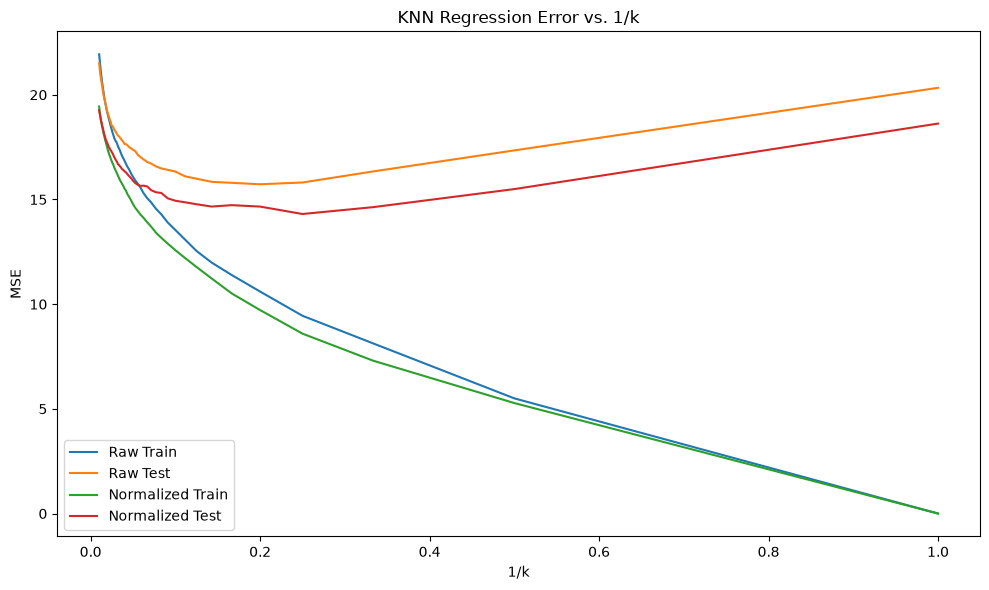

In [24]:
inverse_k = [1 / k for k in k_values]

plt.figure(figsize=(10, 6))

plt.plot(inverse_k, raw_train_mse, label='Raw Train')
plt.plot(inverse_k, raw_test_mse, label='Raw Test')
plt.plot(inverse_k, norm_train_mse, label='Normalized Train')
plt.plot(inverse_k, norm_test_mse, label='Normalized Test')

plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression Error vs. 1/k')
plt.legend()

plt.tight_layout()
plt.show()

Lowest raw data MSE is 15.73 at $k = 5$ and lowest normalized data MSE is 14.31 at $k = 4$. The above is a plot of train/test error against $1/k$.

### (j ) Compare KNN and Linear

In [25]:
best_knn_mse = min(min(raw_test_mse), min(norm_test_mse))

if min(raw_test_mse) < min(norm_test_mse):
    best_knn_type = 'Raw'
    best_knn_k = best_raw_k
else:
    best_knn_type = 'Normalized'
    best_knn_k = best_norm_k

print('Best KNN:', best_knn_type)
print('Best k:', best_knn_k)
print('KNN Test MSE:', best_knn_mse)
print('Regression Test MSE:', reduced_test_mse)

Best KNN: Normalized
Best k: 4
KNN Test MSE: 14.305669422675024
Regression Test MSE: 18.694346190808588


The normalized KNN gives the best MSE at 14.31 at $k = 4$. The KNN captured the non linear relations between PE and predictors better than regression based models (the best test MSE for reduced non linear regression is 18.69).

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible model would perform better in this scenario as the large number of observations reduce the risk of overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

An inflexible model would perform better in this scenario as having lots of predictors but not enough observations makes it more prone to overfitting

### (c) The relationship between the predictors and response is highly non-linear.

A flexible model would perform better in this scenario as it can capture the non linear relationships better.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

An inflexible model would perform better in this scenario since a flexible model would try to accommodate for the high variance and might lead to overfitting.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [26]:
X = np.array([
    [0, 3, 0],
    [2, 0, 0],
    [0, 1, 3],
    [0, 1, 2],
    [-1, 0, 1],
    [1, 1, 1]
])

Y = ["Red", "Red", "Red", "Green", "Green", "Red"]
test_point = np.array([0, 0, 0])

distances = np.linalg.norm(X - test_point, axis=1)

df = pd.DataFrame({
    "Data Point": [list(x) for x in X],
    "Distance from Test Point": distances.round(2),
    "Class": Y
})

df["Rank"] = df["Distance from Test Point"].rank().astype(int)

df.index = range(1, len(df) + 1)

df

,Data Point,Distance from Test Point,Class,Rank
1,"[0, 3, 0]",3.00,Red,5
2,"[2, 0, 0]",2.00,Red,3
3,"[0, 1, 3]",3.16,Red,6
4,"[0, 1, 2]",2.24,Green,4
5,"[-1, 0, 1]",1.41,Green,1
6,"[1, 1, 1]",1.73,Red,2


### (b) What is our prediction with K = 1? Why?

For k = 1, the prediction is Green. It's closest to index 5 which is green.

### (c) What is our prediction with K = 3? Why?

For k = 3, the prediction is Red. The 3 closest points (index 5, 6, 2) are Green, Red and Red respectively. Since the majority is Red the prediction is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

A smaller K value would be better as a larger K value would produce a smoother less flexible decision boundary. While a smaller K would keep the boundary more flexible and adhere to the non linear relation better.

### AI Use log:

**Prompt:**
I’ve attached my Homework 2 assignment PDF for context. Can you walk me through how to approach each part of Question 1 without solving them? Explain the steps I should take and include relevant Python functions and suggested variable names so I can implement and test the solutions myself.

(Uploaded hw2.pdf for context)

**Response:**
### 1(c) Simple Linear Regression

For each predictor (`AT`, `V`, `AP`, and `RH`), fit a separate linear regression model with `PE` as the response. Store the models and examine the coefficient, p-value, and \(R^2\).

```python
simple_models = {}

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df['PE']
    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model
```

Use `model.summary()` to inspect the results. Create scatterplots with the fitted regression line to describe the relationships and check for possible outliers.

### 1(d) Multiple Regression

Fit one regression model using all four predictors:

```python
multiple_model = smf.ols(
    'PE ~ AT + V + AP + RH',
    data=df
).fit()

print(multiple_model.summary())
```

Look at the p-values for the predictors and use your chosen significance level to determine which null hypotheses can be rejected.

### 1(e) Compare the Regression Coefficients

Extract the coefficients from the simple regression models and the multiple regression model:

```python
simple_coefs = [simple_models[p].params[p] for p in predictors]
multiple_coefs = [multiple_model.params[p] for p in predictors]
```

Plot the simple-regression coefficients on the x-axis and the multiple-regression coefficients on the y-axis. Label each point with its predictor and compare how the coefficients change.

### 1(f) Nonlinear Association

For each predictor, fit a model containing the predictor, its squared term, and its cubed term:

```python
model = smf.ols(
    'PE ~ X + I(X**2) + I(X**3)',
    data=df
).fit()
```

Repeat this for each predictor and examine the p-values of the quadratic and cubic terms to determine whether there is evidence of a nonlinear association.

### 1(g) Interaction Terms

Fit a model containing all pairwise interactions:

```python
interaction_model = smf.ols(
    'PE ~ (AT + V + AP + RH)**2',
    data=df
).fit()

print(interaction_model.summary())
```

Check the p-values of the interaction terms and identify which, if any, are statistically significant.

### 1(h) Improve the Model

Split the data into 70% training and 30% testing data:

```python
X = df[predictors]
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
```

Fit the basic linear model and calculate train and test MSE. Then fit a model with quadratic terms and pairwise interactions, remove insignificant variables using p-values, and calculate its train and test MSE.

Compare the two models using their train and test MSE values.

### 1(i) KNN Regression

Test every value of \(k\) from 1 to 100 using the training and test sets:

```python
k_values = range(1, 101)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
```

Store the train and test MSE for each \(k\), find the \(k\) with the lowest test MSE, and repeat the process after normalizing the predictors.

Plot the train and test errors against \(1/k\).

### 1(j) Compare the Models

Use the test MSE of the best KNN model and compare it with the test MSEs from the regression models. Describe the difference in performance based on the values you obtained.


### References:

* Statsmodels OLS regression: [https://www.statsmodels.org/stable/regression.html](https://www.statsmodels.org/stable/regression.html)
* Statsmodels formula API and interaction terms: [https://www.statsmodels.org/stable/example_formulas.html](https://www.statsmodels.org/stable/example_formulas.html)
* PolynomialFeatures: [https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
* KNeighborsRegressor: [https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)